# Phase 6 — Training Techniques That Matter: From "It Runs" to "It Works on New Data"

Getting a model to train is the easy part. Look back at the Phase 5 fine-tune: training accuracy
hit 100% within three epochs. That sounds wonderful and means almost nothing. The only number
anyone cares about is how the model does on data it has **never seen** — and a model can be
perfect on its training data and poor on everything else.

### The student who memorised the answers

Two students prepare for a maths exam using last year's past papers.

- **Student A** works through the problems until they understand the methods.
- **Student B** memorises the answers. *Question 4 is 17. Question 7 is x = 3.*

On the past papers, Student B scores 100% — higher than Student A. Then the real exam arrives
with new questions, and Student B has nothing.

That's **overfitting**: a model that has memorised its training data instead of learning the
patterns that would carry over to new data. Neural networks have enormous capacity to memorise,
so this is the normal thing that happens unless you actively prevent it.

The opposite failure exists too. **Underfitting** is a student who didn't study enough, or wasn't
capable of following the material. They do badly on the practice papers *and* the real exam.

This notebook is about telling those two apart, and about the techniques that push a model from
memorising towards understanding.

### The vocabulary

| Term | What it actually means |
|---|---|
| training set | The practice papers — what the model learns from |
| validation set | Mock exams — used to make decisions (when to stop, which settings win) |
| test set | The real exam — looked at **once**, at the very end |
| overfitting | Great on training data, poor on new data: memorising |
| underfitting | Poor on both: not learning enough |
| generalisation | Doing well on data you've never seen — the actual goal |
| data augmentation | Showing slightly altered copies of the training images, so memorising is harder |
| dropout | Randomly switching off parts of the network while training |
| weight decay | A constant gentle pull on every weight back towards zero |
| batch normalisation | Rescaling each layer's outputs to a steady range during training |
| learning-rate schedule | Changing the step size as training goes on — big early, small late |
| early stopping | Stopping when the validation score stops improving, and keeping the best version |

## What this notebook covers
```
train / validation / test discipline -> reading loss curves (overfit vs underfit, measured)
    -> data augmentation -> dropout, weight decay, batchnorm -> learning-rate schedules
    -> early stopping & checkpoints -> all of it together
    -> does it help the Phase 5 transfer-learning model? (measured, not assumed)
```

## Section 1 — Three Piles of Data, and Why You Need All Three

Phases 3 to 5 used two piles: training and test. That was fine while we trained once and reported
a number. It stops being fine the moment you start **making decisions**.

Every time you look at a score and change something — more epochs, a different learning rate, stop
now — you are tuning to whatever data produced that score. Do it with the test set, and after
twenty rounds of tweaking you've quietly fitted your choices to the test set. Its score no longer
tells you how you'd do on genuinely new data. You've been sneaking looks at the real exam.

So we split three ways:

| Pile | Exam analogy | What you do with it |
|---|---|---|
| **Training** | Practice papers | The model learns from it |
| **Validation** | Mock exams | **You** make every decision from it: when to stop, which recipe wins |
| **Test** | The real exam | Looked at once, at the end, to report an honest number |

The validation set is **carved out of the training data** — the test set stays sealed.

### Our dataset for this phase

We need a problem where overfitting genuinely hurts, so we'll train a CNN **from scratch** on a
deliberately small slice of **CIFAR-10**: 32×32 colour photos in 10 classes — planes, cars,
birds, cats, deer, dogs, frogs, horses, ships and trucks.

- **Training:** 5,000 images (500 per class)
- **Validation:** a *different* 5,000 from the training pool
- **Test:** CIFAR-10's official 10,000 test images, untouched

In [1]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

CLASSES = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
# The average and spread of each colour channel across CIFAR-10, used to centre the inputs
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

plain = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])

train_pool = CIFAR10(root="data", train=True, download=True, transform=plain)
test_data = CIFAR10(root="data", train=False, download=True, transform=plain)

# ── CARVE TRAINING AND VALIDATION OUT OF THE SAME POOL, WITH NO OVERLAP ──────
rng = np.random.default_rng(0)
targets = np.array(train_pool.targets)
train_idx, val_idx = [], []
for c in range(10):
    shuffled = rng.permutation(np.where(targets == c)[0])
    train_idx += shuffled[:500].tolist()          # 500 of each class to learn from
    val_idx += shuffled[500:1000].tolist()        # a DIFFERENT 500 of each class for decisions

assert not set(train_idx) & set(val_idx), "training and validation must never share an image"

val_loader = DataLoader(Subset(train_pool, val_idx), batch_size=500)
test_loader = DataLoader(test_data, batch_size=500)

print(f"training   : {len(train_idx):,} images  (practice papers)")
print(f"validation : {len(val_idx):,} images  (mock exams)")
print(f"test       : {len(test_data):,} images (the real exam -- not touched until the end)")

Using device: mps
training   : 5,000 images  (practice papers)
validation : 5,000 images  (mock exams)
test       : 10,000 images (the real exam -- not touched until the end)


### One training function for the whole notebook

We're about to train several models and compare them, so it's worth writing the loop once. It's
the same five steps as always, plus two additions:

- after every epoch it scores the **validation** set and records **both** training and validation
  loss and accuracy — you can't diagnose anything without both
- it optionally accepts a **scheduler** and an **early stopper**, which we build later in this
  notebook. Until then they're simply switched off.

In [2]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    """One pass over a loader. Trains if an optimizer is given, otherwise just measures."""
    training = optimizer is not None
    model.train(training)                                   # train() or eval() mode
    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(training):                  # no graph needed when only measuring
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            seen += labels.size(0)
    return total_loss / seen, correct / seen


def fit(model, train_loader, optimizer, epochs, label, scheduler=None, early_stopper=None, report_every=5):
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, loss_fn)

        for key, value in zip(history, (train_loss, val_loss, train_acc, val_acc, optimizer.param_groups[0]["lr"])):
            history[key].append(value)

        if scheduler is not None:                           # Section 5
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)                    # this kind needs to be told the score
            else:
                scheduler.step()

        if epoch % report_every == 0 or epoch == 1:
            print(f"[{label}] epoch {epoch:2d} | train loss {train_loss:.3f} acc {train_acc:.0%} | "
                  f"val loss {val_loss:.3f} acc {val_acc:.1%}")

        if early_stopper is not None and early_stopper.step(val_loss, model, epoch):   # Section 6
            print(f"[{label}] stopping early at epoch {epoch}: no improvement for "
                  f"{early_stopper.patience} epochs (best was epoch {early_stopper.best_epoch})")
            break

    print(f"[{label}] finished in {time.time() - start:.0f}s")
    return history

## Section 2 — Reading the Curves: Overfitting vs Underfitting

The single most useful diagnostic in deep learning is **one chart: training loss and validation
loss, plotted together over the epochs.** Its shape tells you which problem you have, and so which
fix to reach for.

| What you see | Diagnosis | Everyday version | What helps |
|---|---|---|---|
| Both losses high and close together | **Underfitting** | Didn't learn the material | A bigger model, longer training, less regularisation |
| Training keeps falling, validation turns and **rises** | **Overfitting** | Memorising the answers | Everything in the rest of this notebook |
| Both fall and level off close together | Healthy | Understood it | Nothing to fix |

Let's produce both failure modes on purpose.

**Too simple:** shrink every photo to a blurry **4×4-pixel thumbnail**, then hand those 48 numbers to
a single `Linear` layer. Try telling a cat from a dog from 16 coloured squares — there simply isn't
enough to work with, however long you study.

**Too free:** a proper CNN, trained with no protection against memorising — no augmentation, no
dropout, no weight decay, a fixed learning rate — for 40 epochs.

In [3]:
def make_cnn(batchnorm=False, dropout=0.0):
    """Three conv blocks, then a small classifier. The switches let us add techniques later."""
    def block(c_in, c_out):
        layers = [nn.Conv2d(c_in, c_out, 3, padding=1)]
        if batchnorm: layers.append(nn.BatchNorm2d(c_out))
        layers += [nn.ReLU(), nn.Conv2d(c_out, c_out, 3, padding=1)]
        if batchnorm: layers.append(nn.BatchNorm2d(c_out))
        layers += [nn.ReLU(), nn.MaxPool2d(2)]
        return layers
    return nn.Sequential(
        *block(3, 32), *block(32, 64), *block(64, 128),     # 32x32 -> 16 -> 8 -> 4
        nn.Flatten(),
        nn.Dropout(dropout), nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
        nn.Dropout(dropout), nn.Linear(256, 10),
    )

train_loader = DataLoader(Subset(train_pool, train_idx), batch_size=128, shuffle=True)

# ── TOO SIMPLE: A 4x4 THUMBNAIL AND ONE LINEAR LAYER ─────────────────────────
torch.manual_seed(0)
too_simple = nn.Sequential(
    nn.AvgPool2d(8),                   # average each 8x8 patch: 32x32 photo -> blurry 4x4 thumbnail
    nn.Flatten(),                      # 3 colours x 4 x 4 = just 48 numbers
    nn.Linear(3 * 4 * 4, 10),          # one layer, no hidden layers, no convolution
).to(device)
hist_simple = fit(too_simple, train_loader, optim.Adam(too_simple.parameters(), lr=1e-3),
                  epochs=15, label="too simple")

# ── TOO FREE: A REAL CNN WITH NO PROTECTION AGAINST MEMORISING ───────────────
torch.manual_seed(0)
baseline = make_cnn().to(device)
hist_baseline = fit(baseline, train_loader, optim.Adam(baseline.parameters(), lr=1e-3),
                    epochs=40, label="baseline CNN")

[too simple] epoch  1 | train loss 2.292 acc 14% | val loss 2.207 acc 17.6%
[too simple] epoch  5 | train loss 2.037 acc 28% | val loss 2.034 acc 28.1%
[too simple] epoch 10 | train loss 1.960 acc 31% | val loss 1.969 acc 30.6%
[too simple] epoch 15 | train loss 1.923 acc 32% | val loss 1.933 acc 32.0%
[too simple] finished in 6s
[baseline CNN] epoch  1 | train loss 2.122 acc 20% | val loss 3.033 acc 14.6%
[baseline CNN] epoch  5 | train loss 1.554 acc 42% | val loss 1.531 acc 43.1%
[baseline CNN] epoch 10 | train loss 1.197 acc 57% | val loss 1.420 acc 49.6%
[baseline CNN] epoch 15 | train loss 0.745 acc 73% | val loss 1.514 acc 53.1%
[baseline CNN] epoch 20 | train loss 0.201 acc 93% | val loss 2.478 acc 54.1%
[baseline CNN] epoch 25 | train loss 0.059 acc 98% | val loss 3.260 acc 52.9%
[baseline CNN] epoch 30 | train loss 0.063 acc 98% | val loss 3.344 acc 53.5%
[baseline CNN] epoch 35 | train loss 0.036 acc 99% | val loss 3.909 acc 52.8%
[baseline CNN] epoch 40 | train loss 0.003 a

too simple    final train acc 32% | final val acc 32.0% | val loss: best 1.93 at epoch 15, final 1.93
baseline CNN  final train acc 100% | final val acc 52.5% | val loss: best 1.41 at epoch 12, final 5.20


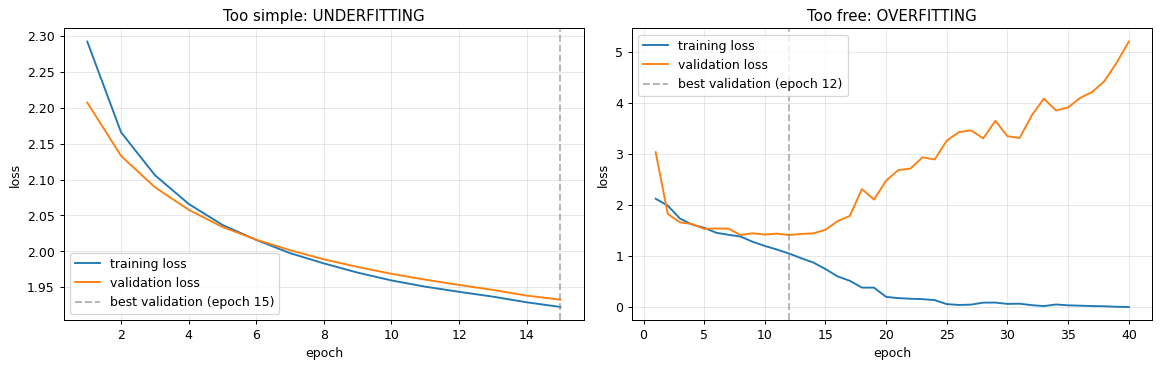

In [4]:
def plot_diagnosis(ax, history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="training loss")
    ax.plot(epochs, history["val_loss"], label="validation loss")
    best = int(np.argmin(history["val_loss"]))
    ax.axvline(best + 1, color="gray", linestyle="--", alpha=0.6, label=f"best validation (epoch {best + 1})")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.legend(); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_diagnosis(axes[0], hist_simple, "Too simple: UNDERFITTING")
plot_diagnosis(axes[1], hist_baseline, "Too free: OVERFITTING")
plt.tight_layout(); plt.show()

for name, h in (("too simple", hist_simple), ("baseline CNN", hist_baseline)):
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<13} final train acc {h['train_acc'][-1]:.0%} | final val acc {h['val_acc'][-1]:.1%} | "
          f"val loss: best {h['val_loss'][best]:.2f} at epoch {best + 1}, final {h['val_loss'][-1]:.2f}")

### What the two charts are telling you

**Too simple (left)** — both losses fall a little, then flatten out **together**, high up. Training
accuracy ends at 32% and validation at 32%: the model does exactly as badly on photos it has seen as on
photos it hasn't. It isn't memorising anything — it simply isn't capable of more. This is the one
situation where the techniques in this notebook would make things **worse**, because they all make
learning *harder*. The cure for underfitting is more capacity: a real model.

**Too free (right)** — a completely different shape. Training loss dives to almost nothing and training
accuracy hits **100%**. Validation loss improves until **epoch 12**, then turns round and climbs, finishing
at **5.20 — nearly four times its best of 1.41**. From epoch 12 onwards, every step of training made the
model *worse* at the only thing we care about.

The gap is the story: **100% on the practice papers, 52.5% on the mock exam.** That gap is memorisation.

### A subtle thing: the loss exploded, the accuracy didn't

Look at the printed log rather than the chart. Validation *loss* nearly quadrupled, yet validation
*accuracy* barely moved — 49.6% at epoch 10, still 52.5% at epoch 40.

How can the error grow that much while the score stays flat? Because cross-entropy doesn't just count
mistakes, it measures **how confident** each mistake was (Phase 3). The model kept getting roughly the
same half of the photos right, but became *extraordinarily sure of itself* on the half it got wrong. A
model that says "definitely a truck, 99.9%" about a photo of a deer is dangerous in a way its accuracy
will never show you.

So **watch validation loss, not just accuracy.** It is usually the earlier warning.

## Section 3 — Data Augmentation: Make Memorising Harder

The most effective fix for overfitting on images is also the most intuitive one.

If the student is memorising the practice papers, **stop showing them the exact same papers.**
Change the numbers slightly each time. Now memorising doesn't work, and the only way to keep
scoring well is to actually learn the method.

**Data augmentation** does that for images. Every time a training image is used, it's randomly
altered in ways that **don't change what it is**:

- **flip it left-to-right** — a cat facing left is still a cat
- **shift it a few pixels** — a slightly off-centre car is still a car
- **nudge the brightness, contrast and colour** — a horse on a cloudy day is still a horse

Over 40 epochs, the model never sees exactly the same picture twice. It *can't* memorise pixel
patterns, so it's pushed towards features that survive those changes: shapes, parts, textures.

### The two rules

**1. Only augment the training data.** Validation and test must stay untouched — you want to
measure the model on real images, not randomly wobbled ones.

**2. The change must not alter the correct answer.** Flipping a photo of a car left-to-right is
fine. Flipping a handwritten `6` upside down gives you a `9` with the label still saying `6` — now
you're teaching the model something false. Every augmentation is a claim about what doesn't
matter for your problem, so choose them with that in mind.

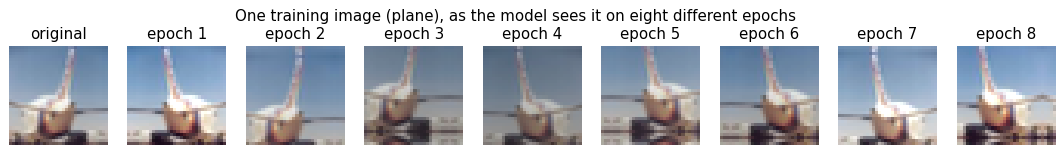

In [5]:
# ── THE AUGMENTATION PIPELINE ────────────────────────────────────────────────
augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode="reflect"),   # shift by up to 4 pixels
    transforms.RandomHorizontalFlip(),                              # mirror, 50% of the time
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),   # slight lighting changes
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ── WHAT THE MODEL SEES: ONE IMAGE, EIGHT DIFFERENT EPOCHS ───────────────────
raw_pool = CIFAR10(root="data", train=True, download=False)        # no transform: raw PIL images
image, label = raw_pool[train_idx[7]]

def to_displayable(t):
    mean, std = torch.tensor(CIFAR_MEAN).view(3, 1, 1), torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0)            # undo Normalize, channels last

torch.manual_seed(3)
fig, axes = plt.subplots(1, 9, figsize=(15, 2))
axes[0].imshow(image); axes[0].set_title("original"); axes[0].axis("off")
for i, ax in enumerate(axes[1:], 1):
    ax.imshow(to_displayable(augment(image)))                      # a fresh random version each call
    ax.set_title(f"epoch {i}"); ax.axis("off")
plt.suptitle(f"One training image ({CLASSES[label]}), as the model sees it on eight different epochs")
plt.show()

All eight are still unmistakably the same picture to you. To a network trying to memorise exact
pixel values, they're eight different images.

Now the real test: **train the identical CNN from Section 2, changing only one thing** — the
training images go through `augment` instead of `plain`. Same model, same optimizer, same 40
epochs.

[augmentation only] epoch  1 | train loss 2.177 acc 18% | val loss 1.964 acc 26.1%
[augmentation only] epoch  5 | train loss 1.674 acc 37% | val loss 1.666 acc 38.0%
[augmentation only] epoch 10 | train loss 1.428 acc 46% | val loss 1.344 acc 51.4%
[augmentation only] epoch 15 | train loss 1.252 acc 54% | val loss 1.253 acc 56.0%
[augmentation only] epoch 20 | train loss 1.141 acc 59% | val loss 1.128 acc 60.1%
[augmentation only] epoch 25 | train loss 0.970 acc 65% | val loss 1.043 acc 63.7%
[augmentation only] epoch 30 | train loss 0.885 acc 68% | val loss 1.012 acc 64.8%
[augmentation only] epoch 35 | train loss 0.805 acc 71% | val loss 0.942 acc 67.9%
[augmentation only] epoch 40 | train loss 0.724 acc 74% | val loss 0.915 acc 68.9%
[augmentation only] finished in 68s


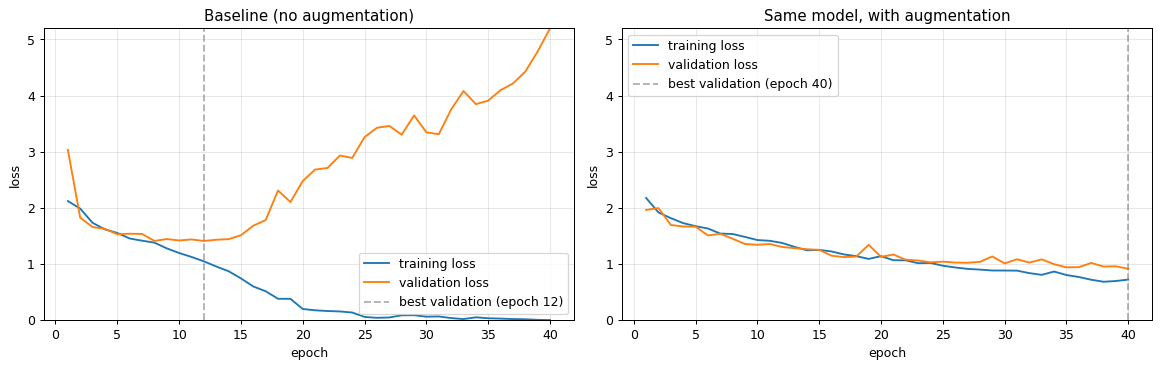

In [6]:
augmented_pool = CIFAR10(root="data", train=True, download=False, transform=augment)
augmented_loader = DataLoader(Subset(augmented_pool, train_idx), batch_size=128, shuffle=True)
# (val_loader is unchanged: validation images are NEVER augmented)

torch.manual_seed(0)
aug_only = make_cnn().to(device)
hist_aug = fit(aug_only, augmented_loader, optim.Adam(aug_only.parameters(), lr=1e-3),
               epochs=40, label="augmentation only")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_diagnosis(axes[0], hist_baseline, "Baseline (no augmentation)")
plot_diagnosis(axes[1], hist_aug, "Same model, with augmentation")
for ax in axes: ax.set_ylim(0, max(max(hist_baseline["val_loss"]), 2.5))
plt.tight_layout(); plt.show()

Same model, one change, and a completely different picture:

- **Training accuracy ends at 74%, not 100%.** The model *can't* memorise images that never look the same
  twice. On the practice papers, it now looks *worse* than the baseline.
- **Validation loss falls steadily for all 40 epochs** — from 1.96 down to 0.92, with no upturn at all.
  The baseline's best was 1.41.
- **Validation accuracy reaches 68.9%**, against the baseline's 52.5%.

That first point deserves a moment: **a lower training score turned out to be the better model.** If you
only ever watched training accuracy, you'd conclude augmentation had made things worse.

The curve is also still heading down at epoch 40, which says this model would benefit from training for
longer — something the baseline, finished improving by epoch 12, never could.

## Section 4 — Three More Defences: Dropout, Weight Decay, BatchNorm

Augmentation changes the **data**. These three change the **model or the training**.

### Dropout — no single part can carry the load

You met this in Phase 3. During training, a random fraction of values are switched off each step.
Think of a team where, every day, a random half of the members are off sick. Nobody can become the
one person everything depends on, so knowledge gets spread across the whole team. The network is
forced into redundant, robust features instead of fragile shortcuts.

One detail worth knowing: when half the values are switched off, the survivors are **doubled**, so
the total signal stays the same size. At evaluation time dropout switches off entirely — which is
why `model.eval()` matters.

### Weight decay — a gentle pull towards simple

Every step, each weight is nudged slightly towards zero. A weight only stays large if the data keeps
pushing it there. The effect is a preference for simpler solutions — fewer extreme weights, less
room to fit noise.

**Use `AdamW`, not `Adam`, when you want weight decay.** Plain `Adam` accepts a `weight_decay`
argument, but it mixes the decay into the gradient, where Adam's per-parameter scaling then distorts
it. `AdamW` applies the decay directly and separately, which is what you actually meant. It's a
one-letter change that makes weight decay work as intended.

### Batch normalisation — keep every layer's numbers steady

As training progresses, the range of values coming out of each layer drifts, and every layer after
it has to keep re-adjusting to a moving target. **BatchNorm** rescales each layer's outputs to a
steady average and spread, using the statistics of the current batch.

It's mainly a **stabiliser**: it lets you train faster with higher learning rates. It regularises a
little as a side effect, because each batch's statistics are slightly noisy.

Like dropout, it **behaves differently in training and evaluation**, and this one bites people. In
training it uses the current batch's statistics. In evaluation it uses a running average it has been
quietly collecting — because a prediction shouldn't depend on which other images happen to share its
batch. Let's watch both behaviours.

In [7]:
torch.manual_seed(0)

# ── DROPOUT: SWITCHED-OFF VALUES, AND SURVIVORS SCALED UP ────────────────────
dropout = nn.Dropout(p=0.5)
x = torch.ones(10)
dropout.train()
print("dropout in train mode:", dropout(x).tolist())
print("  -> about half are 0, and the survivors are 2.0, so the total stays roughly the same")
dropout.eval()
print("dropout in eval mode :", dropout(x).tolist(), " <- switched off entirely")

# ── BATCHNORM: BATCH STATISTICS WHILE TRAINING, RUNNING AVERAGE WHEN EVALUATING ──
bn = nn.BatchNorm1d(num_features=1)
print(f"\nbatchnorm's running average before any data: {bn.running_mean.item():.2f}")

bn.train()
for _ in range(50):                                        # show it 50 batches centred around 5
    bn(torch.randn(32, 1) + 5.0)
print(f"after 50 training batches centred on 5     : {bn.running_mean.item():.2f}  <- learned quietly")

single = torch.tensor([[5.0], [5.5]])                      # a tiny batch
bn.train(); in_train = bn(single).detach().squeeze().tolist()
bn.eval();  in_eval = bn(single).detach().squeeze().tolist()
print(f"\nsame two inputs, train mode: {[round(v, 2) for v in in_train]}  <- uses THIS batch's own average")
print(f"same two inputs, eval mode : {[round(v, 2) for v in in_eval]}  <- uses the running average instead")

# ── WEIGHT DECAY: USE AdamW ──────────────────────────────────────────────────
example_model = make_cnn()
optimizer = optim.AdamW(example_model.parameters(), lr=1e-3, weight_decay=0.05)
print(f"\n{type(optimizer).__name__} with weight_decay={optimizer.param_groups[0]['weight_decay']} "
      f"-- decay applied directly, not mixed into the gradient")

dropout in train mode: [0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 2.0, 2.0, 0.0, 2.0]
  -> about half are 0, and the survivors are 2.0, so the total stays roughly the same
dropout in eval mode : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]  <- switched off entirely

batchnorm's running average before any data: 0.00
after 50 training batches centred on 5     : 4.96  <- learned quietly

same two inputs, train mode: [-1.0, 1.0]  <- uses THIS batch's own average
same two inputs, eval mode : [0.01, 0.53]  <- uses the running average instead

AdamW with weight_decay=0.05 -- decay applied directly, not mixed into the gradient


## Section 5 — Learning-Rate Schedules: Fast Early, Careful Late

Think about parking a car. On the open road you drive fast — you're a long way from where you
want to be. As you approach the space you slow right down, because now small, precise movements
are what matter. Arriving at motorway speed means overshooting.

Training is the same. Early on the weights are far from good, and big steps make fast progress.
Later they're close, and big steps just bounce around the bottom of the valley without settling
into it. A **learning-rate schedule** lowers the step size as training goes on.

The three you'll use most:

| Scheduler | What it does | Good for |
|---|---|---|
| `StepLR` | Cuts the rate by a fixed factor every N epochs | Simple and predictable |
| `CosineAnnealingLR` | Glides smoothly from the starting rate down to near zero, following a curve | A great default when you know the epoch count |
| `ReduceLROnPlateau` | Watches the validation loss, and cuts the rate only when it **stops improving** | When you don't know how long training should take |

`ReduceLROnPlateau` is the odd one out: it reacts to your validation loss, so you pass the score in
with `scheduler.step(val_loss)`. The others just count epochs with `scheduler.step()`.

Rather than train three more models, let's draw what each one would do over 40 epochs. For
`ReduceLROnPlateau`, we'll feed it the **real validation losses from our overfitting baseline** in
Section 2 and see when it would have stepped in.

ReduceLROnPlateau would have cut the learning rate at epochs: [17, 21, 25, 29, 33, 37]


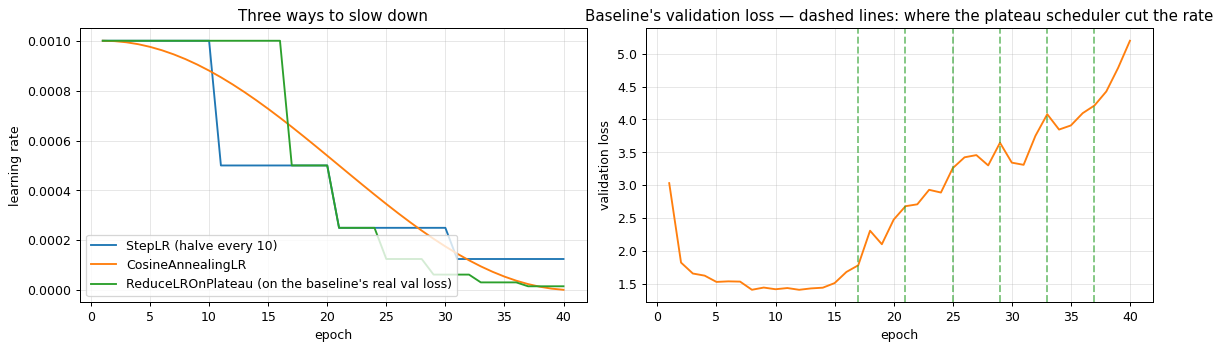

In [8]:
def lr_over_time(make_scheduler, epochs=40, val_losses=None):
    param = nn.Parameter(torch.zeros(1))
    opt = optim.SGD([param], lr=1e-3)
    scheduler = make_scheduler(opt)
    rates = []
    for epoch in range(epochs):
        rates.append(opt.param_groups[0]["lr"])
        if val_losses is not None:
            scheduler.step(val_losses[epoch])       # plateau: needs the validation score
        else:
            scheduler.step()                        # the others: just count epochs
    return rates

step_lr = lr_over_time(lambda o: optim.lr_scheduler.StepLR(o, step_size=10, gamma=0.5))
cosine = lr_over_time(lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=40))
plateau = lr_over_time(lambda o: optim.lr_scheduler.ReduceLROnPlateau(o, factor=0.5, patience=3),
                       val_losses=hist_baseline["val_loss"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, 41)
axes[0].plot(epochs, step_lr, label="StepLR (halve every 10)")
axes[0].plot(epochs, cosine, label="CosineAnnealingLR")
axes[0].plot(epochs, plateau, label="ReduceLROnPlateau (on the baseline's real val loss)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("learning rate"); axes[0].set_title("Three ways to slow down")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, hist_baseline["val_loss"], color="tab:orange")
cuts = [i + 1 for i in range(1, 40) if plateau[i] < plateau[i - 1]]
for c in cuts:
    axes[1].axvline(c, color="tab:green", linestyle="--", alpha=0.6)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation loss")
axes[1].set_title("Baseline's validation loss — dashed lines: where the plateau scheduler cut the rate")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("ReduceLROnPlateau would have cut the learning rate at epochs:", cuts)

Notice what the plateau scheduler reveals about the baseline: it starts cutting shortly after the
validation loss stops improving, and keeps cutting as it gets worse. A schedule can make training
settle more gracefully, but **it cannot rescue a model that's memorising** — slowing down doesn't
help if you're heading the wrong way. That's why schedules are combined with the other techniques
rather than used instead of them.

## Section 6 — Early Stopping, and Keeping the Best Version

Look again at the baseline's curve. Validation loss hit its best well before the halfway mark, and
everything after that made the model worse on new data. All those later epochs were
wasted — or actively harmful.

**Early stopping** watches the validation loss and:

1. every time it reaches a **new best**, saves a copy of the model at that moment
2. counts how many epochs have gone by **without** a new best
3. once that count reaches the **patience** limit, stops training
4. **restores the saved best copy**, so you keep the model from its best moment rather than its last

**Patience** matters because validation loss is noisy — it wobbles up for an epoch or two even when
things are fine. Stop at the first wobble and you quit too early. A patience of 5–10 epochs is typical.

### ⚠️ A silent bug: `state_dict()` is not a snapshot

This one catches almost everyone who writes early stopping by hand. `model.state_dict()` looks like
it returns a copy of the weights. **It doesn't. It returns references to the live tensors.** Save it
as "the best model", keep training, and your "best" changes along with every update. At the end you
"restore the best version" — and get the last one. No error, no warning.

Let's catch it in the act.

In [9]:
def pretend_training_continues(model):
    with torch.no_grad():
        model.weight.fill_(999.0)                        # later epochs change the weights

# ── THE BUG: state_dict() ────────────────────────────────────────────────────
torch.manual_seed(0)
tiny = nn.Linear(2, 1)
print("weights at the 'best' epoch  :", tiny.weight.tolist())
best_so_far = tiny.state_dict()                          # looks like a saved snapshot...
pretend_training_continues(tiny)
print("our saved 'best', afterwards :", best_so_far["weight"].tolist(), " <- overwritten! It was never a copy.")

# ── THE FIX: copy.deepcopy(state_dict()) ─────────────────────────────────────
torch.manual_seed(0)
tiny = nn.Linear(2, 1)
print("\nweights at the 'best' epoch  :", tiny.weight.tolist())
best_so_far = copy.deepcopy(tiny.state_dict())           # a genuine, independent copy
pretend_training_continues(tiny)
print("our saved 'best', afterwards :", best_so_far["weight"].tolist(), " <- still the best epoch's weights")
print("the live model now           :", tiny.weight.tolist())

weights at the 'best' epoch  : [[-0.005293981172144413, 0.37932288646698]]
our saved 'best', afterwards : [[999.0, 999.0]]  <- overwritten! It was never a copy.

weights at the 'best' epoch  : [[-0.005293981172144413, 0.37932288646698]]
our saved 'best', afterwards : [[-0.005293981172144413, 0.37932288646698]]  <- still the best epoch's weights
the live model now           : [[999.0, 999.0]]


In [10]:
class EarlyStopping:
    """Stops training when validation loss stops improving, and remembers the best model."""

    def __init__(self, patience=8, min_improvement=0.0, checkpoint_path=None):
        self.patience = patience                    # how many bad epochs in a row we tolerate
        self.min_improvement = min_improvement      # how much better counts as 'better'
        self.checkpoint_path = checkpoint_path      # optionally ALSO save the best to disk
        self.best_loss = float("inf")
        self.best_epoch = 0
        self.best_state = None
        self.bad_epochs = 0

    def step(self, val_loss, model, epoch):
        """Call once per epoch. Returns True when it's time to stop."""
        if val_loss < self.best_loss - self.min_improvement:
            # a new best: remember it (deepcopy! see the cell above)
            self.best_loss, self.best_epoch, self.bad_epochs = val_loss, epoch, 0
            self.best_state = copy.deepcopy(model.state_dict())
            if self.checkpoint_path:
                torch.save(self.best_state, self.checkpoint_path)   # survives a crash or a restart
        else:
            self.bad_epochs += 1
        return self.bad_epochs >= self.patience

    def restore_best(self, model):
        model.load_state_dict(self.best_state)
        return model

The `checkpoint_path` option writes the best model to disk as well as memory. On a long training run
that's not optional: if your laptop sleeps or the kernel dies at epoch 90, you still have the best
model from epoch 60 instead of nothing.

## Section 7 — Everything Together

Now the assignment for this phase: take the overfitting baseline and apply the full recipe.

| Technique | Setting |
|---|---|
| Data augmentation | crop-shift, horizontal flip, colour jitter |
| Batch normalisation | after every convolution |
| Dropout | 30% in the classifier |
| Weight decay | 0.05, via `AdamW` |
| Learning-rate schedule | `CosineAnnealingLR` over 40 epochs |
| Early stopping | patience 10, best model restored and checkpointed to disk |

Same architecture family, same data, same starting learning rate, same 40-epoch budget.

In [11]:
torch.manual_seed(0)
full_recipe = make_cnn(batchnorm=True, dropout=0.3).to(device)
optimizer = optim.AdamW(full_recipe.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
stopper = EarlyStopping(patience=10, checkpoint_path="phase6_best_cnn.pth")

hist_full = fit(full_recipe, augmented_loader, optimizer, epochs=40, label="full recipe",
                scheduler=scheduler, early_stopper=stopper)

stopper.restore_best(full_recipe)
print(f"\nrestored the best model from epoch {stopper.best_epoch} "
      f"(validation loss {stopper.best_loss:.3f}), also saved to phase6_best_cnn.pth")

[full recipe] epoch  1 | train loss 1.955 acc 26% | val loss 1.643 acc 39.1%
[full recipe] epoch  5 | train loss 1.410 acc 48% | val loss 1.338 acc 48.4%
[full recipe] epoch 10 | train loss 1.196 acc 56% | val loss 1.258 acc 55.8%
[full recipe] epoch 15 | train loss 0.993 acc 64% | val loss 0.961 acc 65.5%
[full recipe] epoch 20 | train loss 0.861 acc 69% | val loss 0.908 acc 67.2%
[full recipe] epoch 25 | train loss 0.744 acc 73% | val loss 0.817 acc 71.8%
[full recipe] epoch 30 | train loss 0.628 acc 77% | val loss 0.774 acc 73.5%
[full recipe] epoch 35 | train loss 0.559 acc 80% | val loss 0.710 acc 75.8%
[full recipe] epoch 40 | train loss 0.530 acc 81% | val loss 0.706 acc 76.1%
[full recipe] finished in 79s

restored the best model from epoch 37 (validation loss 0.705), also saved to phase6_best_cnn.pth


                      train acc  best val loss   TEST accuracy
baseline                  100%          1.412          52.2%
augmentation only          74%          0.915          67.4%
full recipe                81%          0.705          74.4%


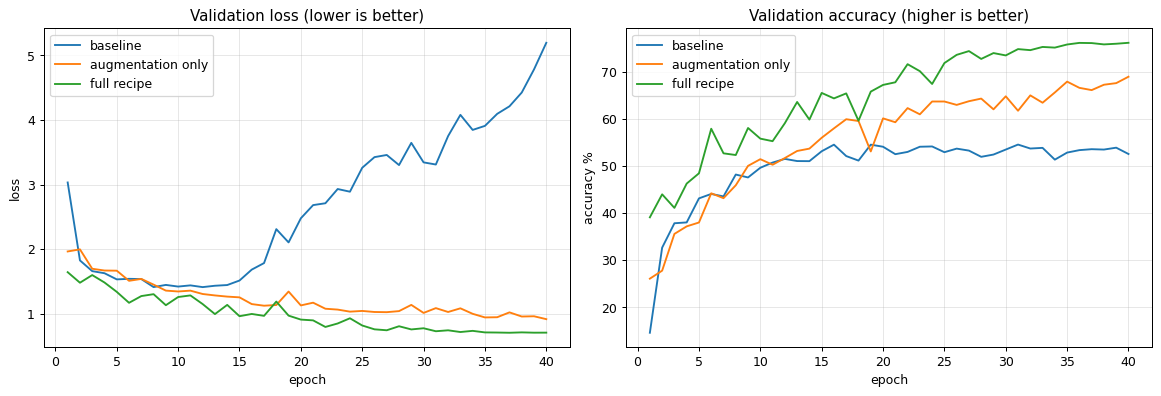

In [12]:
# ── THE COMPARISON: VALIDATION CURVES ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
runs = {"baseline": hist_baseline, "augmentation only": hist_aug, "full recipe": hist_full}
for name, h in runs.items():
    e = range(1, len(h["val_loss"]) + 1)
    axes[0].plot(e, h["val_loss"], label=name)
    axes[1].plot(e, [100 * a for a in h["val_acc"]], label=name)
axes[0].set_title("Validation loss (lower is better)"); axes[0].set_ylabel("loss")
axes[1].set_title("Validation accuracy (higher is better)"); axes[1].set_ylabel("accuracy %")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── THE REAL EXAM: THE TEST SET, OPENED FOR THE FIRST TIME ───────────────────
loss_fn = nn.CrossEntropyLoss()
print(f"{'':<20}{'train acc':>11}{'best val loss':>15}{'TEST accuracy':>16}")
for name, model, h in (("baseline", baseline, hist_baseline),
                       ("augmentation only", aug_only, hist_aug),
                       ("full recipe", full_recipe, hist_full)):
    _, test_acc = run_epoch(model, test_loader, loss_fn)
    print(f"{name:<20}{h['train_acc'][-1]:>10.0%}{min(h['val_loss']):>15.3f}{test_acc:>15.1%}")

### The result

| | Training accuracy | **Test accuracy** |
|---|---|---|
| Baseline | 100% | **52.2%** |
| + augmentation | 74% | **67.4%** |
| + everything | 81% | **74.4%** |

**From 52% to 74% on the same 5,000 images, with the same basic architecture.** No extra data, no bigger
model — just training it in a way that makes memorising hard and understanding worthwhile. Augmentation
did most of the work (+15 points); batchnorm, dropout, weight decay and the schedule together added
another 7.

A few more things worth reading out of those numbers:

- **Validation predicted the test score well.** The full recipe sat around 76% on validation and scored
  74.4% on test. That's exactly what a validation set is for: a trustworthy stand-in you can consult as
  often as you like, so the test set only needs opening once.
- **Early stopping never fired.** The best epoch was 37 of 40, because with these defences in place the
  model was still genuinely improving. That's fine. Early stopping is insurance — it doesn't improve a
  model on its own. It earns its keep in the next section.
- **Is a 22-point gap just luck?** While preparing this notebook I repeated the three runs with a different
  random seed and got 50.6%, 66.9% and 74.6%. Same story.

One honest note on method: we just scored three models on the test set. In a real project you'd use the
validation scores to choose *one* recipe, and open the test set for that one only. Here, the comparison
itself is the lesson.

## Section 8 — Does It Help the Phase 5 Transfer-Learning Model?

The roadmap's assignment for this phase was to take the **Phase 5** model — the pretrained ResNet18
fine-tuned on 400 cat and dog photos — and apply exactly these techniques. So let's do that, and
measure it honestly.

Phase 5 tested on just 200 images. At that size, a gap of 4 or 5 points can easily be luck: a
handful of borderline photos landing one way or the other. So here we test on **all 2,000** cat and
dog images in CIFAR-10's test set, and validate on 500 more carved from the training pool.

Same 400 training images as Phase 5. Two runs:

- **Baseline:** fine-tune everything, no augmentation, no weight decay, constant learning rate
- **Full recipe:** augmentation, dropout in the new head, `AdamW` weight decay, cosine schedule, and
  early stopping with the best model restored

In [13]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
imagenet = weights.transforms()
CAT, DOG = 3, 5
cat_dog_label = lambda y: 0 if y == CAT else 1

rn_plain = transforms.Compose([transforms.Resize(224), transforms.ToTensor(),
                               transforms.Normalize(imagenet.mean, imagenet.std)])
rn_augment = transforms.Compose([transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
                                 transforms.RandomHorizontalFlip(),
                                 transforms.ColorJitter(0.3, 0.3, 0.3),
                                 transforms.Resize(224), transforms.ToTensor(),
                                 transforms.Normalize(imagenet.mean, imagenet.std)])

def cat_dog_subset(targets, n_per_class, seed, exclude=()):
    rng = np.random.default_rng(seed)
    targets = np.array(targets)
    chosen = []
    for c in (CAT, DOG):
        pool = np.setdiff1d(np.where(targets == c)[0], np.array(sorted(exclude), dtype=int))
        chosen.extend(rng.choice(pool, size=n_per_class, replace=False).tolist())
    rng.shuffle(chosen)
    return chosen

cd_plain = CIFAR10("data", train=True, transform=rn_plain, target_transform=cat_dog_label)
cd_aug = CIFAR10("data", train=True, transform=rn_augment, target_transform=cat_dog_label)
cd_test = CIFAR10("data", train=False, transform=rn_plain, target_transform=cat_dog_label)

cd_train_idx = cat_dog_subset(cd_plain.targets, 200, seed=42)            # the same 400 as Phase 5
cd_val_idx = cat_dog_subset(cd_plain.targets, 250, seed=7, exclude=cd_train_idx)
cd_test_idx = cat_dog_subset(cd_test.targets, 1000, seed=42)             # every cat and dog in the test set

val_loader = DataLoader(Subset(cd_plain, cd_val_idx), batch_size=64)      # fit() reads this global
cd_test_loader = DataLoader(Subset(cd_test, cd_test_idx), batch_size=64)
print(f"train {len(cd_train_idx)} | validation {len(cd_val_idx)} | test {len(cd_test_idx)}")

def resnet_for_cats_and_dogs(head_dropout=0.0):
    model = resnet18(weights=weights)
    model.fc = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(512, 2))
    return model.to(device)

def two_speed_optimizer(model, weight_decay):
    head = [p for n, p in model.named_parameters() if n.startswith("fc")]
    backbone = [p for n, p in model.named_parameters() if not n.startswith("fc")]
    return optim.AdamW([{"params": head, "lr": 1e-3}, {"params": backbone, "lr": 1e-4}],
                       weight_decay=weight_decay)

# ── BASELINE ─────────────────────────────────────────────────────────────────
torch.manual_seed(0)
rn_base = resnet_for_cats_and_dogs()
hist_rn_base = fit(rn_base, DataLoader(Subset(cd_plain, cd_train_idx), batch_size=32, shuffle=True),
                   two_speed_optimizer(rn_base, weight_decay=0.0), epochs=20, label="ResNet baseline",
                   report_every=4)

# ── FULL RECIPE ──────────────────────────────────────────────────────────────
torch.manual_seed(0)
rn_full = resnet_for_cats_and_dogs(head_dropout=0.3)
rn_opt = two_speed_optimizer(rn_full, weight_decay=0.05)
rn_stopper = EarlyStopping(patience=8)
hist_rn_full = fit(rn_full, DataLoader(Subset(cd_aug, cd_train_idx), batch_size=32, shuffle=True),
                   rn_opt, epochs=25, label="ResNet full recipe",
                   scheduler=optim.lr_scheduler.CosineAnnealingLR(rn_opt, T_max=25),
                   early_stopper=rn_stopper, report_every=4)
rn_stopper.restore_best(rn_full)

print(f"\n{'':<22}{'train acc':>11}{'best val loss':>15}{'TEST acc (2,000 images)':>26}")
for name, model, h in (("ResNet baseline", rn_base, hist_rn_base), ("ResNet full recipe", rn_full, hist_rn_full)):
    _, acc = run_epoch(model, cd_test_loader, loss_fn)
    print(f"{name:<22}{h['train_acc'][-1]:>10.0%}{min(h['val_loss']):>15.3f}{acc:>25.1%}")

train 400 | validation 500 | test 2000
[ResNet baseline] epoch  1 | train loss 0.512 acc 74% | val loss 0.437 acc 78.8%
[ResNet baseline] epoch  4 | train loss 0.009 acc 100% | val loss 0.426 acc 86.0%
[ResNet baseline] epoch  8 | train loss 0.002 acc 100% | val loss 0.463 acc 85.2%
[ResNet baseline] epoch 12 | train loss 0.001 acc 100% | val loss 0.527 acc 84.0%
[ResNet baseline] epoch 16 | train loss 0.001 acc 100% | val loss 0.524 acc 85.2%
[ResNet baseline] epoch 20 | train loss 0.000 acc 100% | val loss 0.536 acc 84.8%
[ResNet baseline] finished in 79s
[ResNet full recipe] epoch  1 | train loss 0.589 acc 69% | val loss 0.508 acc 72.8%
[ResNet full recipe] epoch  4 | train loss 0.150 acc 95% | val loss 0.428 acc 84.2%
[ResNet full recipe] epoch  8 | train loss 0.105 acc 96% | val loss 0.509 acc 81.6%
[ResNet full recipe] stopping early at epoch 11: no improvement for 8 epochs (best was epoch 3)
[ResNet full recipe] finished in 44s

                        train acc  best val loss  

### No difference — and that is the lesson

**83.8% against 83.7%.** The same recipe that added 22 points to the from-scratch CNN did nothing
measurable for the pretrained model.

It wasn't the result I expected, so I checked it while preparing this notebook. In two extra runs with
different random seeds, the recipe came out 0.3 points ahead, then 2.1 points behind. Small gaps, in both
directions: noise.

### The trap this avoided

An early version of this comparison used Phase 5's **200-image** test set, and the recipe won clearly:
**83.0% against 78.5%**. It would have been very easy to write that up as a success.

It was luck. With 200 test images, every photo is worth half a percentage point, so just nine borderline
photos landing the other way produces that entire gap. Testing on 2,000 images made it vanish.
**Before you believe an improvement, ask whether your test set is big enough to tell it apart from noise.**

### Why it didn't help: diagnose first

Apply Section 2's table to the ResNet baseline's own log:

- **Training accuracy hit 100% by epoch 4.** It memorised its 400 photos, just like the from-scratch CNN.
- **But validation accuracy never collapsed:** 86.0% at epoch 4, still 84.8% at epoch 20.
- **Validation loss only drifted up gently**, from a best of 0.40 to 0.54 — nothing like the from-scratch
  CNN's climb from 1.41 to 5.20.

This model memorised its training photos, but the memorising **cost it nothing** on new photos. Its
judgement comes mostly from the pretrained backbone — features learned from 1.2 million ImageNet images —
and memorising a few hundred cats and dogs doesn't undo that. There was no damaging overfitting for these
techniques to cure.

> **Regularisation fixes overfitting that costs you accuracy. It is not a free upgrade.**
>
> Diagnose from the curves before reaching for it. If validation accuracy isn't suffering, your effort is
> better spent elsewhere: more data, a stronger pretrained backbone, higher-resolution images.

### Where the recipe *did* earn its keep here

Look at the timing lines. Early stopping ended the recipe's run at **epoch 11**, in **44 seconds** against
the baseline's 79 — the same accuracy for just over half the compute. On a model that trains for days
rather than seconds, that alone justifies it.

## Phase 6 Summary

### Cheat sheet
```
Three piles of data:
  training   -> the model learns from it
  validation -> YOU make every decision from it (when to stop, which recipe wins)
  test       -> opened once, at the end, to report an honest number

Diagnose from the curves BEFORE treating anything:
  both losses high and close together          -> underfitting: MORE capacity, LESS regularisation
  training loss falls, validation loss rises    -> overfitting: the techniques below
  validation loss rises but accuracy stays flat -> growing overconfident on its mistakes

Data augmentation (training data ONLY; must never change the right answer):
  transforms.RandomCrop(32, padding=4, padding_mode="reflect")
  transforms.RandomHorizontalFlip()
  transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

In the model and optimizer:
  nn.Dropout(p=0.3)          -> random values switched off while training; off entirely in eval()
  nn.BatchNorm2d(channels)   -> steadies each layer: batch statistics in train, running averages in eval
  optim.AdamW(params, lr=1e-3, weight_decay=0.05)    <- AdamW, not Adam, for weight decay

Learning-rate schedules:
  StepLR(opt, step_size=10, gamma=0.5)            scheduler.step()
  CosineAnnealingLR(opt, T_max=epochs)            scheduler.step()
  ReduceLROnPlateau(opt, factor=0.5, patience=3)  scheduler.step(val_loss)   <- needs the score

Early stopping and checkpoints:
  best = copy.deepcopy(model.state_dict())   <- deepcopy! state_dict() is NOT a snapshot
  torch.save(best, "best.pth")               <- survives a crash or restart
  stop after `patience` epochs with no new best; then model.load_state_dict(best)

What we measured:
  from-scratch CNN, 5,000 CIFAR-10 images : 52.2%  ->  +augmentation 67.4%  ->  full recipe 74.4%
  pretrained ResNet18, 400 cat/dog photos  : 83.8% baseline vs 83.7% full recipe (no real difference)
  a "+4.5 point win" on a 200-image test set turned out to be noise
```

### The five things worth memorising

1. **Diagnose before you treat.** Underfitting and overfitting need opposite fixes, and the loss curves
   tell you which one you have.
2. **Validation for decisions, test for the final report.** Every decision made on the test set quietly
   spoils it.
3. **For small image datasets, augmentation is the biggest single lever** — it was worth 15 points here.
4. **A lower training score can mean a better model.** Judge on validation, never on training.
5. **Regularisation is a cure, not an upgrade** — and small test sets produce convincing-looking wins that
   are really noise.

### Test yourself before moving on

1. Would `transforms.RandomVerticalFlip()` be a sensible augmentation for CIFAR-10? What about for
   satellite photos, or for handwritten digits?
2. Train Section 2's "too simple" model with the full recipe. Predict first: better or worse? Why?
3. Remove `copy.deepcopy` from `EarlyStopping` and rerun Section 7 with `patience=3`. What does
   `restore_best` actually give you back?
4. With a 200-image test set, how many images is one percentage point? How large a gap would you want to see
   before trusting it?

### Up next — Phase 7: Sequence Models
Data that arrives in order — sentences, prices, audio. RNNs, LSTMs and GRUs, and an LSTM that reads 25,000
real movie reviews.